### Importação das bibliotecas necessárias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.over_sampling import SMOTE

%matplotlib inline

# Define o estilo visual padrão para os gráficos do Seaborn
sns.set_theme(style="whitegrid")

RANDOM_STATE = 42

### Carregamento dos dados

In [2]:
# Carregando a base de treino
df_train = pd.read_csv('../train.csv')

# Carregando a base de teste
df_test = pd.read_csv('../test.csv')

print(f"Dimensões do Dataset de Treino: {df_train.shape[0]} linhas e {df_train.shape[1]} colunas.")
print(f"Dimensões do Dataset de Teste: {df_test.shape[0]} linhas e {df_test.shape[1]} colunas.")

Dimensões do Dataset de Treino: 32769 linhas e 10 colunas.
Dimensões do Dataset de Teste: 58921 linhas e 10 colunas.


### Visualizando as primeiras linhas

In [3]:
# Olhar a estrutura dos dados
df_train.head()

,ACTION,RESOURCE,MGR_ID,ROLE_ROLLUP_1,ROLE_ROLLUP_2,ROLE_DEPTNAME,ROLE_TITLE,ROLE_FAMILY_DESC,ROLE_FAMILY,ROLE_CODE
0,1,39353,85475,117961,118300,123472,117905,117906,290919,117908
1,1,17183,1540,117961,118343,123125,118536,118536,308574,118539
2,1,36724,14457,118219,118220,117884,117879,267952,19721,117880
3,1,36135,5396,117961,118343,119993,118321,240983,290919,118322
4,1,42680,5905,117929,117930,119569,119323,123932,19793,119325


### Primeira verificação de dados faltantes e tipos

In [4]:
print("--- Informações do Dataset de Treino ---")
df_train.info()

print("\n--- Quantidade de Valores Nulos por Coluna ---")
print(df_train.isnull().sum())

--- Informações do Dataset de Treino ---
<class 'pandas.DataFrame'>
RangeIndex: 32769 entries, 0 to 32768
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   ACTION            32769 non-null  int64
 1   RESOURCE          32769 non-null  int64
 2   MGR_ID            32769 non-null  int64
 3   ROLE_ROLLUP_1     32769 non-null  int64
 4   ROLE_ROLLUP_2     32769 non-null  int64
 5   ROLE_DEPTNAME     32769 non-null  int64
 6   ROLE_TITLE        32769 non-null  int64
 7   ROLE_FAMILY_DESC  32769 non-null  int64
 8   ROLE_FAMILY       32769 non-null  int64
 9   ROLE_CODE         32769 non-null  int64
dtypes: int64(10)
memory usage: 2.5 MB

--- Quantidade de Valores Nulos por Coluna ---
ACTION              0
RESOURCE            0
MGR_ID              0
ROLE_ROLLUP_1       0
ROLE_ROLLUP_2       0
ROLE_DEPTNAME       0
ROLE_TITLE          0
ROLE_FAMILY_DESC    0
ROLE_FAMILY         0
ROLE_CODE           0
dtype: int64


### Análise do Desbalanceamento da Target

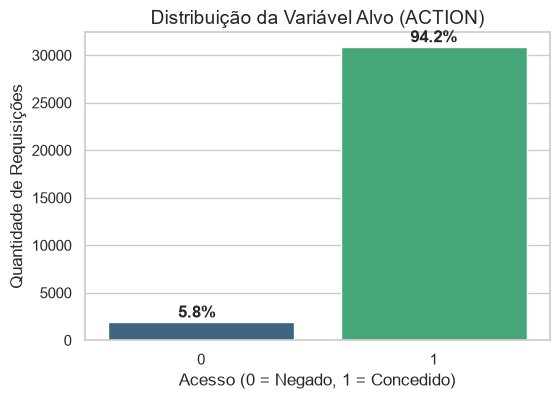


Valores absolutos:
ACTION
1    30872
0     1897
Name: count, dtype: int64


In [5]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='ACTION', data=df_train, hue='ACTION', palette='viridis', legend=False)

# Adicionando a porcentagem em cima das barras
total = len(df_train)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x_coord = p.get_x() + p.get_width() / 2 - 0.1
    y_coord = p.get_height() + 500
    ax.annotate(percentage, (x_coord, y_coord), fontsize=12, fontweight='bold')

plt.title('Distribuição da Variável Alvo (ACTION)', fontsize=14)
plt.xlabel('Acesso (0 = Negado, 1 = Concedido)', fontsize=12)
plt.ylabel('Quantidade de Requisições', fontsize=12)
plt.show()

print("\nValores absolutos:")
print(df_train['ACTION'].value_counts())

### Cardinalidade dos atributos

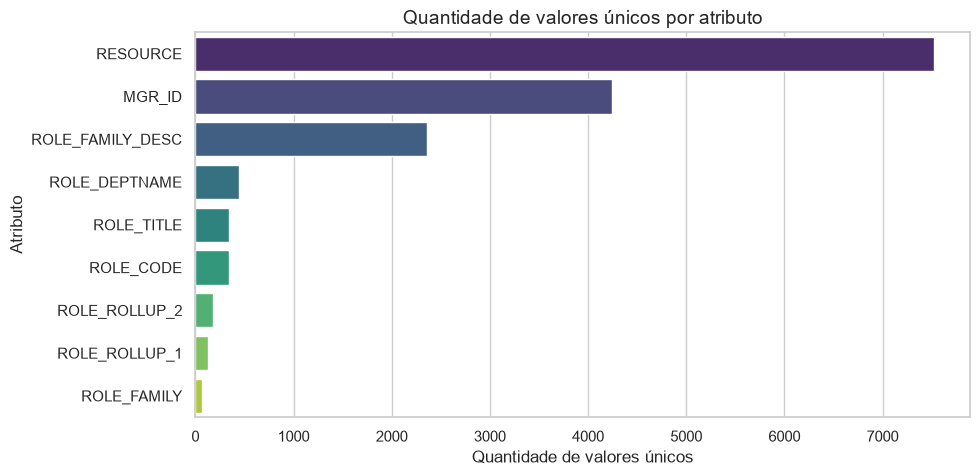

RESOURCE            7518
MGR_ID              4243
ROLE_FAMILY_DESC    2358
ROLE_DEPTNAME        449
ROLE_TITLE           343
ROLE_CODE            343
ROLE_ROLLUP_2        177
ROLE_ROLLUP_1        128
ROLE_FAMILY           67
dtype: int64

In [6]:
# Calculando a quantidade de valores únicos em cada atributo
# Os atributos são códigos numéricos, mas representam categorias do problema
cardinalidade = df_train.drop(columns='ACTION').nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(x=cardinalidade.values, y=cardinalidade.index, hue=cardinalidade.index, palette='viridis', legend=False)
plt.title('Quantidade de valores únicos por atributo', fontsize=14)
plt.xlabel('Quantidade de valores únicos', fontsize=12)
plt.ylabel('Atributo', fontsize=12)
plt.show()

cardinalidade

### Distribuição das categorias mais frequentes


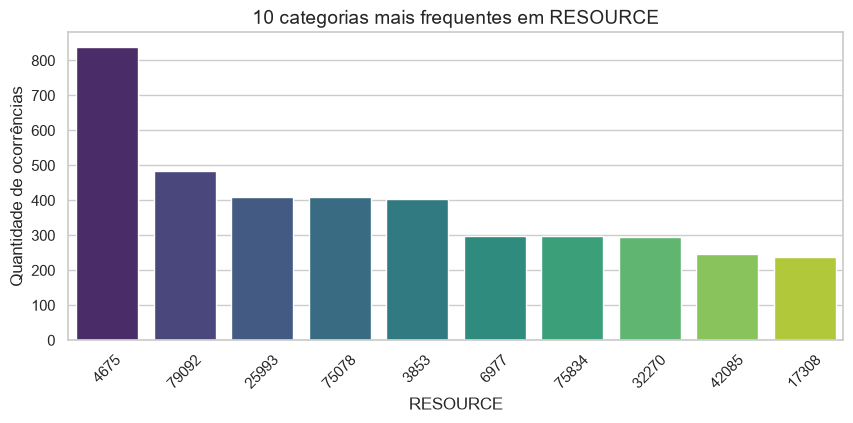

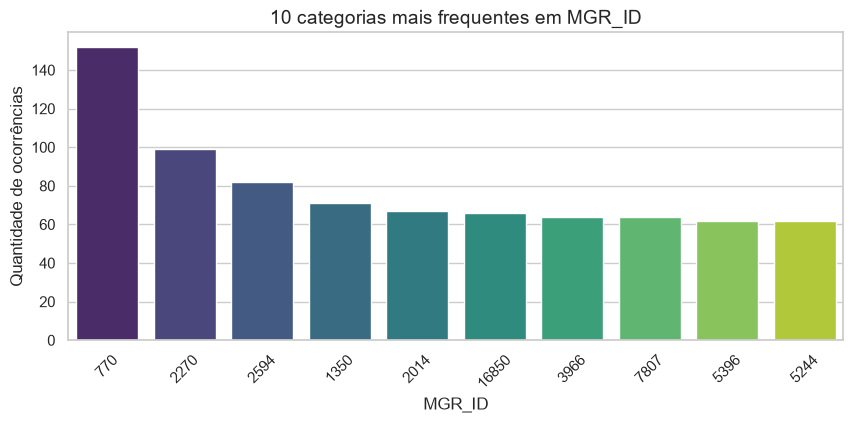

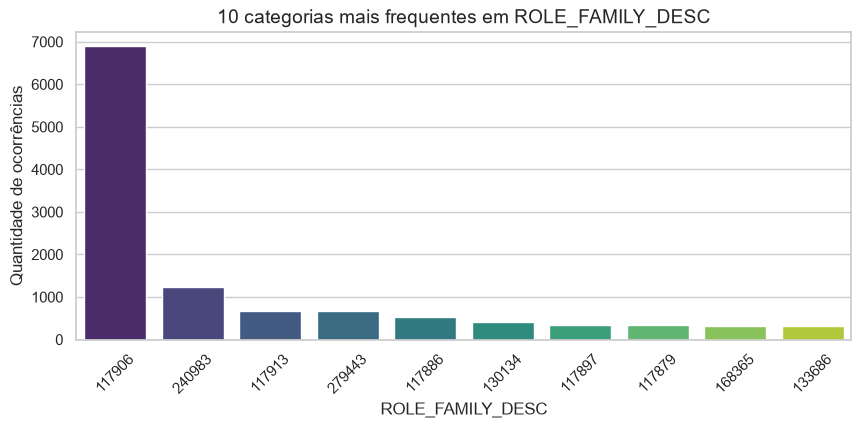

In [7]:
# Visualizando as categorias mais frequentes dos atributos com maior cardinalidade
colunas_maior_cardinalidade = cardinalidade.head(3).index.tolist()

for coluna in colunas_maior_cardinalidade:
    frequencias = df_train[coluna].value_counts().head(10)

    plt.figure(figsize=(10, 4))
    sns.barplot(x=frequencias.index.astype(str), y=frequencias.values, hue=frequencias.index.astype(str), palette='viridis', legend=False)
    plt.title(f'10 categorias mais frequentes em {coluna}', fontsize=14)
    plt.xlabel(coluna, fontsize=12)
    plt.ylabel('Quantidade de ocorrências', fontsize=12)
    plt.xticks(rotation=45)
    plt.show()

### Análise de categorias raras


In [8]:
# Categorias raras podem dificultar a generalização do modelo, principalmente em atributos de alta cardinalidade
# Consideraremos rara quando ela aparecer menos de 5 vezes no treino
limite_categoria_rara = 5
resumo_categorias_raras = []

for coluna in df_train.drop(columns='ACTION').columns:
    contagens = df_train[coluna].value_counts()
    qtd_raras = (contagens < limite_categoria_rara).sum()
    percentual_raras = 100 * qtd_raras / contagens.shape[0]
    resumo_categorias_raras.append({
        'atributo': coluna,
        'categorias_unicas': contagens.shape[0],
        'categorias_raras': qtd_raras,
        'percentual_categorias_raras': percentual_raras
    })

resumo_categorias_raras = pd.DataFrame(resumo_categorias_raras)
resumo_categorias_raras = resumo_categorias_raras.sort_values(by='percentual_categorias_raras', ascending=False)
resumo_categorias_raras

,atributo,categorias_unicas,categorias_raras,percentual_categorias_raras
0,RESOURCE,7518,6328,84.171322
6,ROLE_FAMILY_DESC,2358,1452,61.577608
1,MGR_ID,4243,2269,53.476314
5,ROLE_TITLE,343,79,23.032070
8,ROLE_CODE,343,79,23.032070
4,ROLE_DEPTNAME,449,72,16.035635
3,ROLE_ROLLUP_2,177,27,15.254237
7,ROLE_FAMILY,67,10,14.925373
2,ROLE_ROLLUP_1,128,16,12.500000


### Análise de correlação


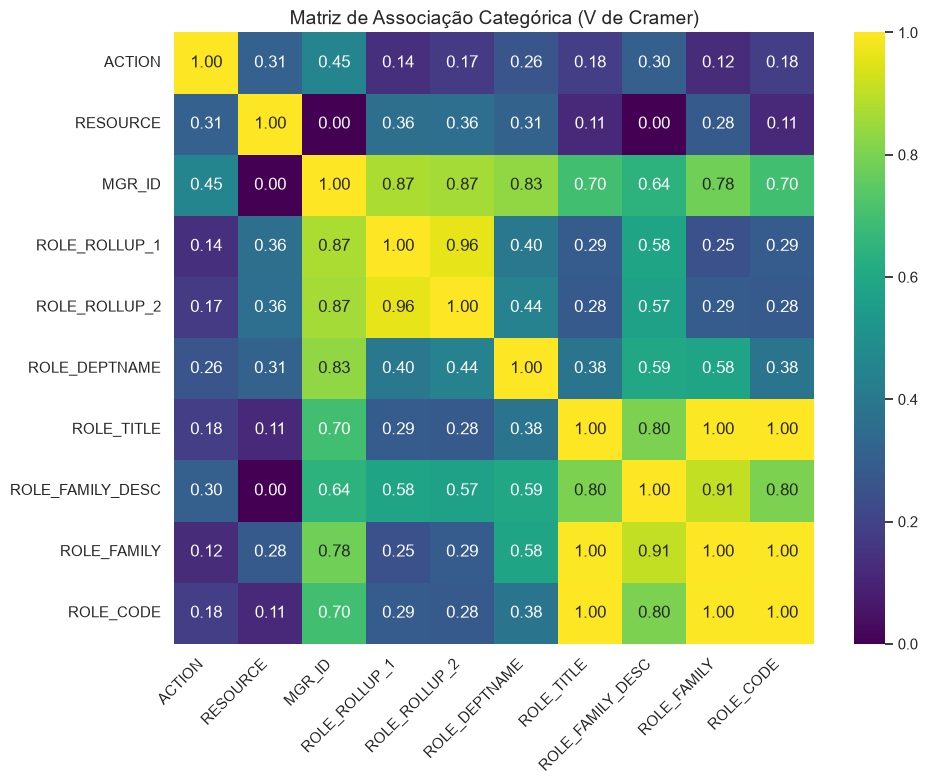

--- Associação com a variável alvo (ACTION) ---


MGR_ID              0.454002
RESOURCE            0.306489
ROLE_FAMILY_DESC    0.298606
ROLE_DEPTNAME       0.264162
ROLE_TITLE          0.181609
ROLE_CODE           0.181609
ROLE_ROLLUP_2       0.174534
ROLE_ROLLUP_1       0.139328
ROLE_FAMILY         0.122257
Name: ACTION, dtype: float64

In [9]:
# 1. Função para calcular o V de Cramer
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    
    # Correção de viés estatístico
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    
    # Prevenção de divisão por zero
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# 2. Pegando todas as colunas do seu dataframe de treino
cols = df_train.columns.tolist()

# 3. Construindo a matriz
cramer_matrix = pd.DataFrame(index=cols, columns=cols)

for col1 in cols:
    for col2 in cols:
        if col1 == col2:
            cramer_matrix.loc[col1, col2] = 1.0
        else:
            cramer_matrix.loc[col1, col2] = cramers_v(df_train[col1], df_train[col2])

# Convertendo os valores para float para o gráfico funcionar
cramer_matrix = cramer_matrix.astype(float)

# 4. Plotando o Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cramer_matrix, cmap='viridis', annot=True, fmt='.2f')
plt.title('Matriz de Associação Categórica (V de Cramer)', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 5. Associação dos atributos com a variável alvo
associacao_target = cramer_matrix['ACTION'].drop('ACTION').sort_values(ascending=False)
print("--- Associação com a variável alvo (ACTION) ---")
display(associacao_target)

### Análise bivariada

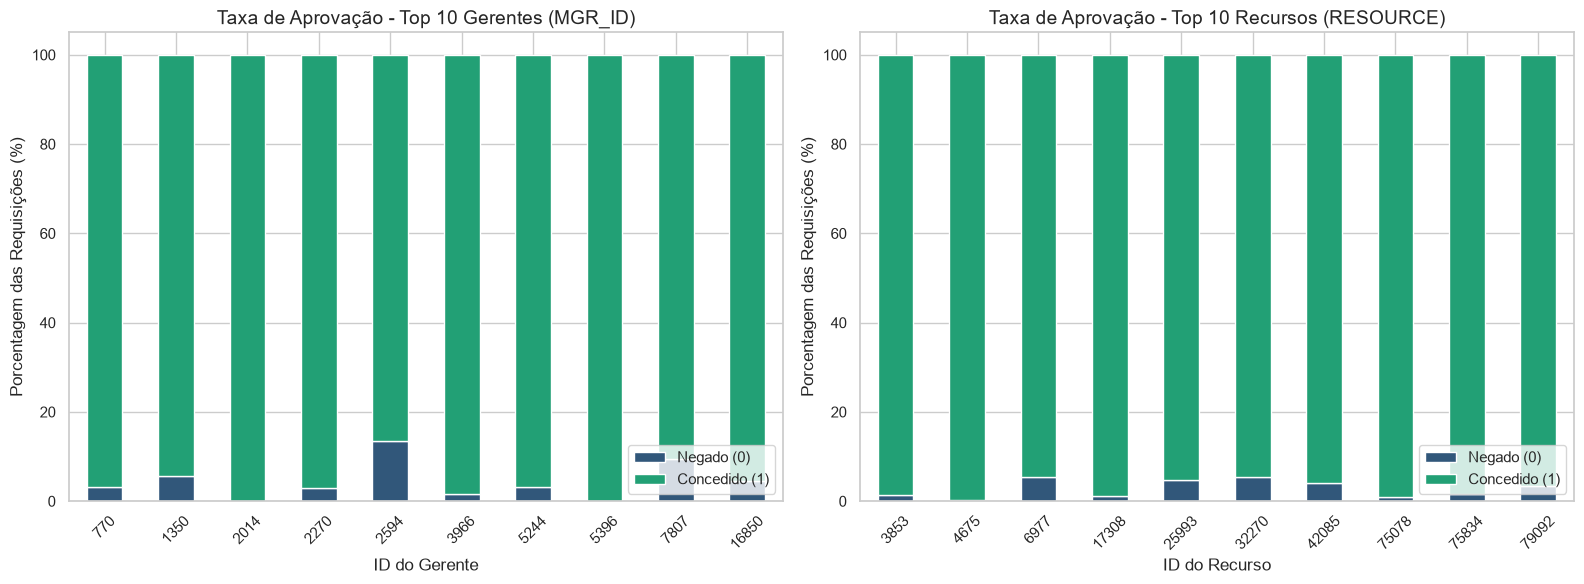

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Negado (0) = Azul, Concedido (1) = Verde
cores = ['#31577a', '#22a075']

# Top 10 Gerentes (MGR_ID) vs Decisão de Acesso (ACTION)
top10_mgr = df_train['MGR_ID'].value_counts().head(10).index
df_top_mgr = df_train[df_train['MGR_ID'].isin(top10_mgr)]

# Criando a tabela de proporção
crosstab_mgr = pd.crosstab(df_top_mgr['MGR_ID'], df_top_mgr['ACTION'], normalize='index') * 100

crosstab_mgr.plot(kind='bar', stacked=True, ax=axes[0], color=cores)
axes[0].set_title('Taxa de Aprovação - Top 10 Gerentes (MGR_ID)', fontsize=14)
axes[0].set_ylabel('Porcentagem das Requisições (%)', fontsize=12)
axes[0].set_xlabel('ID do Gerente', fontsize=12)
axes[0].legend(['Negado (0)', 'Concedido (1)'], loc='lower right')
axes[0].tick_params(axis='x', rotation=45)


# Top 10 Recursos (RESOURCE) vs Decisão de Acesso (ACTION)
top10_res = df_train['RESOURCE'].value_counts().head(10).index
df_top_res = df_train[df_train['RESOURCE'].isin(top10_res)]

# Criando a tabela de proporção
crosstab_res = pd.crosstab(df_top_res['RESOURCE'], df_top_res['ACTION'], normalize='index') * 100

crosstab_res.plot(kind='bar', stacked=True, ax=axes[1], color=cores)
axes[1].set_title('Taxa de Aprovação - Top 10 Recursos (RESOURCE)', fontsize=14)
axes[1].set_ylabel('Porcentagem das Requisições (%)', fontsize=12)
axes[1].set_xlabel('ID do Recurso', fontsize=12)
axes[1].legend(['Negado (0)', 'Concedido (1)'], loc='lower right')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Análise de outliers

In [11]:
# Os atributos do dataset são identificadores categóricos representados por números
# Por isso, valores altos ou baixos não indicam necessariamente outliers
# A análise mais adequada é observar categorias raras e diferenças de distribuição entre treino e teste

colunas_atributos = df_train.drop(columns='ACTION').columns.tolist()
comparacao_categorias = []

for coluna in colunas_atributos:
    categorias_treino = set(df_train[coluna].unique())
    categorias_teste = set(df_test[coluna].unique())
    categorias_novas_teste = categorias_teste - categorias_treino

    comparacao_categorias.append({
        'atributo': coluna,
        'categorias_treino': len(categorias_treino),
        'categorias_teste': len(categorias_teste),
        'categorias_no_teste_e_nao_no_treino': len(categorias_novas_teste)
    })

comparacao_categorias = pd.DataFrame(comparacao_categorias)
comparacao_categorias.sort_values(by='categorias_no_teste_e_nao_no_treino', ascending=False)

,atributo,categorias_treino,categorias_teste,categorias_no_teste_e_nao_no_treino
1,MGR_ID,4243,4689,670
6,ROLE_FAMILY_DESC,2358,2749,593
4,ROLE_DEPTNAME,449,466,27
8,ROLE_CODE,343,351,18
5,ROLE_TITLE,343,351,18
3,ROLE_ROLLUP_2,177,177,6
2,ROLE_ROLLUP_1,128,126,2
7,ROLE_FAMILY,67,68,1
0,RESOURCE,7518,4971,0


### Separação entre treino, validação e teste


In [12]:
# Separando atributos e variável alvo
X = df_train.drop(columns='ACTION')
y = df_train['ACTION']

# Separando um conjunto de teste interno com rótulos para avaliação final
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

# Separando treino e validação a partir dos dados restantes
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print(f"Treino: {X_train.shape[0]} amostras")
print(f"Validação: {X_val.shape[0]} amostras")
print(f"Teste interno: {X_test.shape[0]} amostras")

print("\nDistribuição da variável alvo no treino:")
print(y_train.value_counts(normalize=True).round(4))

print("\nDistribuição da variável alvo na validação:")
print(y_val.value_counts(normalize=True).round(4))

print("\nDistribuição da variável alvo no teste interno:")
print(y_test.value_counts(normalize=True).round(4))

Treino: 19661 amostras
Validação: 6554 amostras
Teste interno: 6554 amostras

Distribuição da variável alvo no treino:
ACTION
1    0.9421
0    0.0579
Name: proportion, dtype: float64

Distribuição da variável alvo na validação:
ACTION
1    0.942
0    0.058
Name: proportion, dtype: float64

Distribuição da variável alvo no teste interno:
ACTION
1    0.9422
0    0.0578
Name: proportion, dtype: float64


### Pré-processamento dos atributos


In [13]:
# Os atributos precisam ser tratados como categóricos
# O OneHotEncoder converte essas categorias em uma representação numérica adequada
# Categorias pouco frequentes são agrupadas para reduzir a dimensionalidade
atributos_categoricos = X_train.columns.tolist()

preprocessador = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(handle_unknown='infrequent_if_exist', min_frequency=10), atributos_categoricos)
    ]
)

print("Atributos categóricos usados no pré-processamento:")
print(atributos_categoricos)

Atributos categóricos usados no pré-processamento:
['RESOURCE', 'MGR_ID', 'ROLE_ROLLUP_1', 'ROLE_ROLLUP_2', 'ROLE_DEPTNAME', 'ROLE_TITLE', 'ROLE_FAMILY_DESC', 'ROLE_FAMILY', 'ROLE_CODE']


### Aplicação do One-Hot Encoding


In [14]:
# Ajustando o pré-processador apenas com os dados de treino, para evitar vazamento de dados (data leakage)
preprocessador.fit(X_train)

# Transformando treino, validação e teste interno com o mesmo encoder ajustado
X_train_proc = preprocessador.transform(X_train)
X_val_proc = preprocessador.transform(X_val)
X_test_proc = preprocessador.transform(X_test)

print(f"Dimensão de X_train após o One-Hot Encoding: {X_train_proc.shape}")
print(f"Dimensão de X_val após o One-Hot Encoding: {X_val_proc.shape}")
print(f"Dimensão de X_test após o One-Hot Encoding: {X_test_proc.shape}")

Dimensão de X_train após o One-Hot Encoding: (19661, 2052)
Dimensão de X_val após o One-Hot Encoding: (6554, 2052)
Dimensão de X_test após o One-Hot Encoding: (6554, 2052)


### Balanceamento de classes com SMOTE


In [15]:
from imblearn.over_sampling import SMOTE

# O SMOTE é aplicado apenas no treino e somente após o One-Hot Encoding,
# criando exemplos sintéticos da classe minoritária (ACTION = 0) por interpolação
# Validação e teste interno não são alterados, para manter a avaliação realista
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_proc, y_train)

print("Distribuição da variável ACTION antes do SMOTE:")
print(y_train.value_counts())

print("\nDistribuição da variável ACTION depois do SMOTE:")
print(pd.Series(y_train_res).value_counts())

Distribuição da variável ACTION antes do SMOTE:
ACTION
1    18523
0     1138
Name: count, dtype: int64

Distribuição da variável ACTION depois do SMOTE:
ACTION
1    18523
0    18523
Name: count, dtype: int64


### Salvando os artefatos para a modelagem


In [16]:
import sys
sys.path.append('..')

# Funções centralizadas em src/preprocessing.py para manter o mesmo pré-processamento
# entre os notebooks de modelagem de cada integrante da equipe
from src.preprocessing import save_processed_data

# Salvando os conjuntos já codificados (treino balanceado com SMOTE, validação e teste
# com a distribuição original) e o preprocessador ajustado, para reuso na modelagem
save_processed_data(
    output_dir='../data/processed',
    preprocessador=preprocessador,
    X_train_res=X_train_res,
    y_train_res=y_train_res,
    X_val=X_val_proc,
    y_val=y_val,
    X_test=X_test_proc,
    y_test=y_test,
)

print("Artefatos salvos em data/processed/:")
print("- X_train_res.npz / y_train_res.npy (treino balanceado com SMOTE)")
print("- X_val.npz / y_val.npy (validação, distribuição original)")
print("- X_test.npz / y_test.npy (teste interno, distribuição original)")
print("- preprocessador.pkl (ColumnTransformer ajustado)")

Artefatos salvos em data/processed/:
- X_train_res.npz / y_train_res.npy (treino balanceado com SMOTE)
- X_val.npz / y_val.npy (validação, distribuição original)
- X_test.npz / y_test.npy (teste interno, distribuição original)
- preprocessador.pkl (ColumnTransformer ajustado)
